In [ ]:
# Chess AI with deep learning
# Christopher Cesar Woodhouse 6246682
# CNT 4149 RVC 1251

# Chess AI with Deep Learning

# Imports & Package Installs

In [ ]:
# package installs
!pip install chess
!pip install stockfish
!pip install cairosvg
!apt-get update
!apt-get install -y stockfish

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.1/6.1 MB 36.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for chess: filename=chess-1.11.2-py3-none-any.whl size=147775 sha256=a9309397e871f9907b299135ef8b6f3fea0bf11c823bdb8b83058b3466a368d0
  Stored in directory: /root/.cache/pip/wheels/fb/5d/5c/59a62d8a695285e59ec9c1f66add6f8a9ac4152499a2be0113
Successfully built chess
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.2/43.2 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.6/75.6 kB 2.7 MB/s eta 0:00:00
Get:1 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Hit:3 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:4 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:5 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:6 https://r2u.stat.illinois.edu/ubuntu jammy InRel

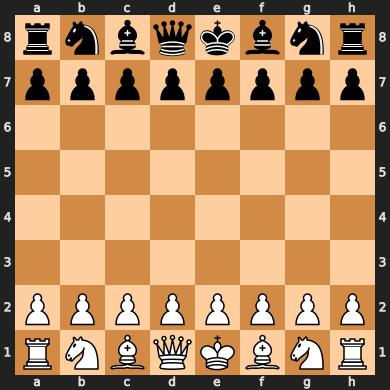

In [ ]:
import chess
import chess.engine
import numpy as np
import chess
import chess.pgn
import os
from tqdm import tqdm
import random
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


board = chess.Board()

board

In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Game Against Stockfish

Note: Main() function must be uncommented to play.

In [ ]:
import chess
import time
from stockfish import Stockfish
from IPython.display import SVG, display

# Set up the board
board = chess.Board()

# Path to the Stockfish executable - you'll need to adjust this
# to the location where you installed the Stockfish binary
# If it's in your PATH environment variable, you might be able to just use "stockfish"
stockfish_path = "/usr/games/stockfish"  # Change this to your path if needed

# Initialize Stockfish engine
try:
    stockfish = Stockfish(path=stockfish_path, depth=15, parameters={"Threads": 2, "Skill Level": 10})
except Exception as e:
    print(f"Error initializing Stockfish: {e}")
    print("Make sure you've downloaded the Stockfish engine from https://stockfishchess.org/download/")
    exit(1)

def print_board(board):
    #print(board)
    display(SVG(chess.svg.board(board=board, size=400)))

def main():
    print("Chess Game Against Computer")
    print("---------------------------")
    print("Enter moves in UCI format (e.g. 'e2e4')")
    print("Type 'quit' to exit")

    # Set initial position
    stockfish.set_position([])

    while not board.is_game_over():
        print_board(board)
        #board

        # Player's turn (white)
        if board.turn == chess.WHITE:
            move_input = input("Your move: ")
            if move_input.lower() == 'quit':
                break

            try:
                move = chess.Move.from_uci(move_input)
                if move in board.legal_moves:
                    # Make the move on our board
                    board.push(move)

                    # Also update the Stockfish engine's board
                    stockfish.make_moves_from_current_position([move_input])
                else:
                    print("Illegal move! Try again.")
                    continue
            except ValueError:
                print("Invalid format! Use UCI notation (e.g. 'e2e4').")
                continue

        # Computer's turn (black)
        else:
            print("Computer is thinking...")
            # Get best move from Stockfish
            best_move = stockfish.get_best_move()
            if best_move:
                # Parse the move and apply it to our board
                move = chess.Move.from_uci(best_move)
                board.push(move)

                # Update Stockfish's internal board
                stockfish.make_moves_from_current_position([best_move])
                print(f"Computer played: {best_move}")
            else:
                print("Stockfish couldn't find a move!")

    print_board(board)
    print("Game over!")
    if board.is_checkmate():
        winner = "Black" if board.turn == chess.WHITE else "White"
        print(f"{winner} wins by checkmate!")
    elif board.is_stalemate():
        print("Game ended in stalemate!")
    elif board.is_insufficient_material():
        print("Game ended due to insufficient material!")

if __name__ == "__main__":
    #main()
    pass

# Generate Additional Data

In [ ]:
import chess
import random

def generate_random_chess_board(game_phase="random"):
    """
    Generate a random valid chess board position using python-chess library.

    Args:
        game_phase (str): "opening", "midgame", "endgame", or "random" to control piece density

    Returns:
        chess.Board: A valid chess position
    """
    # Create an empty board
    board = chess.Board.empty()

    # Determine which game phase to generate
    if game_phase == "random":
        game_phase = random.choice(["opening", "midgame", "endgame"])

    # Configure piece count ranges based on game phase
    if game_phase == "opening":
        white_piece_range = (14, 16)  # Nearly full set of pieces
        black_piece_range = (14, 16)
        pawn_density = (6, 8)      # Most pawns still on board
    elif game_phase == "midgame":
        white_piece_range = (8, 13)  # Some pieces captured
        black_piece_range = (8, 13)
        pawn_density = (4, 7)      # Some pawns traded
    else:  # endgame
        white_piece_range = (2, 7)   # Few pieces left
        black_piece_range = (2, 7)
        pawn_density = (0, 4)      # Few pawns left

    # Place kings first (required for a valid position)
    white_king_square = random.randint(0, 63)
    board.set_piece_at(white_king_square, chess.Piece(chess.KING, chess.WHITE))

    # Find a valid square for the black king (not adjacent to the white king)
    black_king_candidates = list(range(64))
    black_king_candidates.remove(white_king_square)

    # Remove squares adjacent to white king
    white_king_file, white_king_rank = chess.square_file(white_king_square), chess.square_rank(white_king_square)
    for file in range(max(0, white_king_file - 1), min(8, white_king_file + 2)):
        for rank in range(max(0, white_king_rank - 1), min(8, white_king_rank + 2)):
            adjacent_square = chess.square(file, rank)
            if adjacent_square in black_king_candidates:
                black_king_candidates.remove(adjacent_square)

    black_king_square = random.choice(black_king_candidates)
    board.set_piece_at(black_king_square, chess.Piece(chess.KING, chess.BLACK))

    occupied_squares = {white_king_square, black_king_square}

    # Decide on number of pieces for each side
    white_piece_count = random.randint(*white_piece_range)
    black_piece_count = random.randint(*black_piece_range)

    # Determine pawn count for each side
    white_pawn_count = min(8, random.randint(*pawn_density))
    black_pawn_count = min(8, random.randint(*pawn_density))

    # Place white pieces
    remaining_white = white_piece_count - 1  # -1 for the king already placed
    white_pawns_placed = 0
    white_pieces = [chess.QUEEN, chess.ROOK, chess.BISHOP, chess.KNIGHT, chess.PAWN]
    white_piece_weights = [1, 2, 2, 2, 0]  # Initial weights (no pawns yet)

    # Add special weighting for endgame positions (more likely to have specific pieces)
    if game_phase == "endgame":
        # Increase chance of having a queen in endgame
        white_piece_weights[0] = 3

    while remaining_white > 0 and (occupied_squares != set(range(64))):
        if white_pawns_placed < white_pawn_count:
            # Add pawns to the selection pool
            white_piece_weights[4] = 8 - white_pawns_placed
        else:
            white_piece_weights[4] = 0  # No more pawns needed

        piece_type = random.choices(white_pieces, weights=white_piece_weights, k=1)[0]

        if piece_type == chess.PAWN:
            # Pawns can't be on first or last rank
            valid_ranks = range(1, 7)
            while True:
                rank = random.choice(valid_ranks)
                file = random.randint(0, 7)
                square = chess.square(file, rank)
                if square not in occupied_squares:
                    board.set_piece_at(square, chess.Piece(chess.PAWN, chess.WHITE))
                    occupied_squares.add(square)
                    white_pawns_placed += 1
                    break
        else:
            # Place other pieces anywhere
            candidates = [sq for sq in range(64) if sq not in occupied_squares]
            if candidates:
                square = random.choice(candidates)
                board.set_piece_at(square, chess.Piece(piece_type, chess.WHITE))
                occupied_squares.add(square)

        remaining_white -= 1

    # Place black pieces
    remaining_black = black_piece_count - 1  # -1 for the king already placed
    black_pawns_placed = 0
    black_pieces = [chess.QUEEN, chess.ROOK, chess.BISHOP, chess.KNIGHT, chess.PAWN]
    black_piece_weights = [1, 2, 2, 2, 0]  # Initial weights (no pawns yet)

    # Add special weighting for endgame positions (more likely to have specific pieces)
    if game_phase == "endgame":
        # Increase chance of having a queen in endgame
        black_piece_weights[0] = 3

    while remaining_black > 0 and (occupied_squares != set(range(64))):
        if black_pawns_placed < black_pawn_count:
            # Add pawns to the selection pool
            black_piece_weights[4] = 8 - black_pawns_placed
        else:
            black_piece_weights[4] = 0  # No more pawns needed

        piece_type = random.choices(black_pieces, weights=black_piece_weights, k=1)[0]

        if piece_type == chess.PAWN:
            # Pawns can't be on first or last rank
            valid_ranks = range(1, 7)
            while True:
                rank = random.choice(valid_ranks)
                file = random.randint(0, 7)
                square = chess.square(file, rank)
                if square not in occupied_squares:
                    board.set_piece_at(square, chess.Piece(chess.PAWN, chess.BLACK))
                    occupied_squares.add(square)
                    black_pawns_placed += 1
                    break
        else:
            # Place other pieces anywhere
            candidates = [sq for sq in range(64) if sq not in occupied_squares]
            if candidates:
                square = random.choice(candidates)
                board.set_piece_at(square, chess.Piece(piece_type, chess.BLACK))
                occupied_squares.add(square)

        remaining_black -= 1

    # Set a random side to move
    board.turn = random.choice([chess.WHITE, chess.BLACK])

    # Disable castling rights (since we're generating a random position)
    board.castling_rights = 0

    # Clear en passant square (no en passant in random positions)
    board.ep_square = None

    # Verify the position is valid (kings not in check)
    valid_position = is_valid_position(board)

    if not valid_position:
        # Try again if position is invalid
        return generate_random_chess_board(game_phase)

    return board

def is_valid_position(board):
    """Check if the position is valid (no king in check)"""
    # Save original turn
    original_turn = board.turn

    # Check if either king is in check
    for turn in [chess.WHITE, chess.BLACK]:
        board.turn = turn
        opponent_turn = not turn

        # If it's your turn and you're in check, that's invalid
        king_square = board.king(turn)
        if king_square is not None and board.is_check():
            return False

    # Restore original turn
    board.turn = original_turn
    return True

def generate_training_dataset(num_positions=100, game_phase_distribution=None):
    """
    Generate a dataset of random chess positions for AI training.

    Args:
        num_positions (int): Number of positions to generate
        game_phase_distribution (dict): Distribution of positions by game phase
            Example: {'opening': 0.2, 'midgame': 0.5, 'endgame': 0.3}

    Returns:
        list: List of chess.Board objects
    """
    if game_phase_distribution is None:
        # Default distribution - more midgame and endgame positions
        game_phase_distribution = {'opening': 0.2, 'midgame': 0.5, 'endgame': 0.3}

    # Validate distribution sums to 1.0
    total = sum(game_phase_distribution.values())
    if abs(total - 1.0) > 0.001:
        raise ValueError(f"Game phase distribution must sum to 1.0 (got {total})")

    # Calculate how many positions to generate for each phase
    phase_counts = {}
    remaining = num_positions

    for phase, ratio in game_phase_distribution.items():
        if phase != list(game_phase_distribution.keys())[-1]:
            count = int(num_positions * ratio)
            phase_counts[phase] = count
            remaining -= count
        else:
            # Assign remaining to the last phase to avoid rounding issues
            phase_counts[phase] = remaining

    # Generate positions
    positions = []
    for phase, count in phase_counts.items():
        for _ in range(count):
            positions.append(generate_random_chess_board(phase))

    # Shuffle the positions
    random.shuffle(positions)
    return positions

# Example usage
if __name__ == "__main__":
    # Generate one random board
    board = generate_random_chess_board()
    print("Random chess position:")
    print(board)
    print(f"FEN: {board.fen()}")

    # Generate some training data with different game phases
    print("\nGenerating training dataset...")
    training_data = generate_training_dataset(
        num_positions=10,
        game_phase_distribution={'opening': 0.2, 'midgame': 0.5, 'endgame': 0.3}
    )

    print(f"Generated {len(training_data)} positions")
    for i, board in enumerate(training_data[:3]):  # Print first 3 positions
        print(f"\nPosition {i+1}:")
        print(board)

    print("...")  # Indicating there are more positions

Random chess position:
. . . . . . . .
B . . . . . . .
. . . P r . . .
. . . . . . . .
. . . . N k . .
. . . . . . . .
. . . . . . . .
B . . . . . K .
FEN: 8/B7/3Pr3/8/4Nk2/8/8/B5K1 w - - 0 1

Generating training dataset...
Generated 10 positions

Position 1:
. . . . . . . .
. . . . . . . .
r . . . . . P .
. . . . . . . K
. . . . . . . .
. . . . . . . .
r . . . . . . .
. . . k . . . .

Position 2:
b . . B . B n .
k . . . . r q B
. . . . K P . .
. p p . . . . .
. P . Q . p . R
. . p . . . . .
. P . . p P P .
. . . . . . . .

Position 3:
. B . . . . . .
. K p . . P P .
. . . . . . q r
. . . Q r r Q .
k . . . . . . b
p . . R p q p .
. . P . P R n .
. . . . . . . .
...


In [ ]:
# track execution time
from datetime import datetime
start_time = datetime.now()


import chess.engine
stockfish_path = "/usr/games/stockfish"


# generate a bunch of data points and save
num_positions = 12000

# Generate random boards with different game phases
print("\nGenerating training dataset...")
training_data = generate_training_dataset(
    num_positions=num_positions,
    game_phase_distribution={'opening': 0.2, 'midgame': 0.5, 'endgame': 0.3}
)

# use stockfish to calculate a move
print("\nGenerating moves...")
engine = chess.engine.SimpleEngine.popen_uci(stockfish_path)
if engine:
    for board in training_data:
        try:
            result = engine.play(board, chess.engine.Limit(time=0.1))
            board.push(result.move)
            print("boop")
        except:
          print("error")
          engine.quit()
          engine = chess.engine.SimpleEngine.popen_uci(stockfish_path) #restart engine if fail
          training_data.remove(board) # remove this board from the dataset if it causes an error
    engine.quit()

Streaming output truncated to the last 5000 lines.
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop
boop

AttributeError: 'Board' object has no attribute 'is_empty'

In [ ]:
print("\nConverting to dataset...")
positions = []
policy_targets = []
value_targets = []
engine = chess.engine.SimpleEngine.popen_uci(stockfish_path)
# convert the boards and move into training data
for board in training_data:
    # if the board is empty dont pop
    if len(board.move_stack) == 0:
        continue
    move = board.pop()
    info = engine.analyse(board, chess.engine.Limit(time=0.1))
    game_result = info["score"].white().score() if "score" in info and info["score"].white() is not None else 0 # Assign 0 if score is not available

    # Process each position in the game
    position_features, policy_target, value_target = process_single_position(board, move, game_result, engine=engine)

    if value_target is not None:
      positions.append(position_features)
      policy_targets.append(policy_target)
      value_targets.append([value_target])


# save the new dataset
save_dataset(positions, policy_targets, value_targets, save_dir='/content/drive/MyDrive/CNT 4149 Deep Learning/chess_dataset/chess_dataset_randomized.npz')

# tell me how long that took
execution_time = datetime.now() - start_time
print(f"Cell execution time: {execution_time}")


Converting to dataset...
Dataset saved to /content/drive/MyDrive/CNT 4149 Deep Learning/chess_dataset/chess_dataset_randomized.npz
Cell execution time: 0:55:49.229482


#Data Preprocessing & Feature Extraction

In [ ]:
def board_to_features(board):
    """
    Convert a chess board to a feature representation.

    Parameters:
    -----------
    board : chess.Board
        The chess board to convert

    Returns:
    --------
    features : numpy.ndarray
        8x8x14 feature representation of the board
    """
    # Initialize 8x8x14 feature array
    features = np.zeros((8, 8, 14), dtype=np.float32)

    # Channel mappings for pieces
    piece_channels = {
        # White pieces (channels 0-5)
        (chess.PAWN, chess.WHITE): 0,
        (chess.KNIGHT, chess.WHITE): 1,
        (chess.BISHOP, chess.WHITE): 2,
        (chess.ROOK, chess.WHITE): 3,
        (chess.QUEEN, chess.WHITE): 4,
        (chess.KING, chess.WHITE): 5,
        # Black pieces (channels 6-11)
        (chess.PAWN, chess.BLACK): 6,
        (chess.KNIGHT, chess.BLACK): 7,
        (chess.BISHOP, chess.BLACK): 8,
        (chess.ROOK, chess.BLACK): 9,
        (chess.QUEEN, chess.BLACK): 10,
        (chess.KING, chess.BLACK): 11,
    }

    # Fill in piece positions
    for square in chess.SQUARES:
        piece = board.piece_at(square)
        if piece:
            rank = chess.square_rank(square)  # 0-7
            file = chess.square_file(square)  # 0-7
            channel = piece_channels.get((piece.piece_type, piece.color))
            if channel is not None:
                features[rank, file, channel] = 1.0

    # Set the player to move (channel 12)
    features[:, :, 12] = float(board.turn == chess.WHITE)

    # Set castling rights and en passant (channel 13)
    # Combine various board state info into one channel
    if board.has_kingside_castling_rights(chess.WHITE):
        features[0, 4:8, 13] = 1.0
    if board.has_queenside_castling_rights(chess.WHITE):
        features[0, 0:4, 13] = 1.0
    if board.has_kingside_castling_rights(chess.BLACK):
        features[7, 4:8, 13] = 1.0
    if board.has_queenside_castling_rights(chess.BLACK):
        features[7, 0:4, 13] = 1.0

    # Mark en passant square if available
    if board.ep_square is not None:
        rank = chess.square_rank(board.ep_square)
        file = chess.square_file(board.ep_square)
        features[rank, file, 13] = 1.0

    return features


In [ ]:
def process_single_position(board, move, game_result, engine=None):
    """
    Process a single board position and move.

    Args:
        board: A chess.Board object
        move: A chess.Move object
        game_result: Result of the game (1.0 for white win, -1.0 for black win, 0.0 for draw)
        engine: Optional chess engine for evaluation

    Returns:
        tuple: (position_features, policy_target, value_target)
    """
    # Get the player to move
    current_player = 1 if board.turn == chess.WHITE else -1

    # Convert position to input features
    position_features = board_to_features(board)

    # Create policy target
    policy_target = create_improved_policy_target(move, board)

    # Create value target
    value_target = get_value_target(board, game_result, current_player, engine)

    return position_features, policy_target, [value_target]



def get_value_target(board, game_result, current_player, engine=None):
    """
    Get the value target for a position using either Stockfish evaluation or game result.

    Args:
        board: A chess.Board object
        game_result: Result of the game (1.0 for white win, -1.0 for black win, 0.0 for draw)
        current_player: 1 for white, -1 for black
        engine: Optional chess engine for evaluation

    Returns:
        float: Value target between -1.0 and 1.0
    """
    value_target = None

    if engine:
        try:
            info = engine.analyse(board, chess.engine.Limit(time=0.1))
            if "score" in info and info["score"].white() is not None:
                score = info["score"].white().score()
                # Check if score is int before comparing
                if isinstance(score, int):
                    score = max(min(score, 2000), -2000) / 2000
                    value_target = score
                else:
                    game_result = 0.0 if game_result is None else game_result
                    value_target = game_result * current_player  # Fallback
        except (chess.engine.EngineTerminatedError, TimeoutError):
            print("Engine error or timeout. Using game result.")

    # Use fallback if engine failed or wasn't used
    if value_target is None:
        value_target = game_result * current_player

    return value_target

In [ ]:
# function to save the processed data
def save_dataset(positions, policy_targets, value_targets, save_dir):
  np.savez_compressed(save_dir,
                    positions=np.array(positions),
                    policy_targets=np.array(policy_targets),
                    value_targets=np.array(value_targets))

  print(f"Dataset saved to {save_dir}")

In [ ]:
# data preprocessing

# in order to use this i need to make sure the data is in pgn format.

# Process each PGN file
def process_pgn(pgn_files, max_games=None, stockfish_path=None, save_dir='/content/drive/MyDrive/CNT 4149 Deep Learning/chess_dataset/chess_dataset_default.npz'):
    """
    Process PGN files to extract positions, policy targets, and value targets.

    Args:
        pgn_files: List of PGN file paths to process
        max_games: Maximum number of games to process (None for all games)
        stockfish_path: Path to Stockfish engine (None to use game results only)

    Returns:
        tuple: (positions, policy_targets, value_targets) arrays
    """

    import chess # Import chess here
    import chess.pgn # Import chess.pgn here

    positions = []
    policy_targets = []
    value_targets = []

    # Initialize engine if stockfish path provided
    engine = None
    if stockfish_path:
        import chess.engine
        engine = chess.engine.SimpleEngine.popen_uci(stockfish_path)

    try:
        game_count = 0
        for pgn_file in pgn_files:

            # Check if we've reached max_games, in that case break
            if max_games and game_count >= max_games:
                print(f"Reached maximum games limit: {max_games}")
                break

            # every 100 games, save the data to file
            if game_count % 100 == 0:
                print(f"Saving data to {save_dir}...")
                save_dataset(positions, policy_targets, value_targets, save_dir)


            game_count += 1 # else, process this one
            print(f"Processing {pgn_file}...")
            print(f"Games processed so far: {game_count}")

            with io.StringIO(pgn_file) as f:
            #with open(pgn_file) as f:
                while True:


                    # Read game
                    game = chess.pgn.read_game(f)
                    if game is None:  # End of file
                        break

                    # Skip games with variants other than standard chess
                    if game.headers.get("Variant", "Standard") != "Standard":
                        print("Skipping game with non-standard variant.")
                        continue

                    # Extract game result
                    result = game.headers.get("Result", "*")
                    if result == "1-0":
                        game_result = 1.0  # White win
                    elif result == "0-1":
                        game_result = -1.0  # Black win
                    else:
                        game_result = 0.0  # Draw or unknown

                    # Process each position in the game
                    board = game.board()
                    for move in game.mainline_moves():
                        # Get the player to move
                        current_player = 1 if board.turn == chess.WHITE else -1

                        # Convert position to input features
                        position_features = board_to_features(board)

                        # Create policy target (one-hot encoded move)
                        policy_target = create_improved_policy_target(move, board)

                        # Create value target, handling potential timeout
                        value_target = None  # Initialize to None
                        if engine:
                            try:
                                info = engine.analyse(board, chess.engine.Limit(time=0.1))
                                if "score" in info and info["score"].white() is not None:
                                    score = info["score"].white().score()
                                    # check if score is int before comparing
                                    if isinstance(score, int): score = max(min(score, 2000), -2000) / 2000
                                    else: score = game_result * current_player  # Fallback
                                    value_target = score
                                else:
                                    value_target = game_result * current_player  # Fallback
                            except chess.engine.EngineTerminatedError:
                                print("Stockfish terminated unexpectedly. Skipping position.")
                            except TimeoutError:
                                print("Stockfish timed out. Skipping position.")

                        # Use fallback if Stockfish failed or wasn't used
                        if value_target is None:
                            value_target = game_result * current_player

                        # Append to data arrays if value_target was successfully obtained
                        if value_target is not None:
                            positions.append(position_features)
                            policy_targets.append(policy_target)
                            value_targets.append([value_target])

                        # Make the move on the board
                        board.push(move)

                    #game_count += 1
                    #if game_count % 100 == 0:
                    #print(f"Processed {game_count} games...")
    finally:
        # Clean up the engine if it was created
        if engine:
            engine.quit()

    return positions, policy_targets, value_targets

In [ ]:
# Policy Targets

def move_to_dense_policy_target(move):
    """
    Convert a chess move to a policy target index in the 64*64*5 format.

    Args:
        move: A chess.Move object

    Returns:
        An index in the flattened 64*64*5 array
    """
    from_square = move.from_square
    to_square = move.to_square

    # Determine move type (0=regular, 1-4=promotions)
    if move.promotion is None:
        move_type = 0
    else:
        # Map the promotion piece type to an index (1-4)
        promotion_mapping = {
            chess.QUEEN: 1,
            chess.ROOK: 2,
            chess.BISHOP: 3,
            chess.KNIGHT: 4
        }
        move_type = promotion_mapping[move.promotion]

    # Calculate the index in the flattened 64*64*5 array
    index = from_square * (64 * 5) + to_square * 5 + move_type

    return index

def move_to_policy_target(move, board):
    """
    Create a one-hot encoded policy target vector in the 64*64*5 format.

    Args:
        board: Chess board state (needed if you want to mask illegal moves)
        move: The chess move to encode

    Returns:
        A one-hot encoded vector of shape (64*64*5,)
    """
    policy_target = np.zeros(64*64*5, dtype=np.float32)
    index = move_to_dense_policy_target(move)
    policy_target[index] = 1.0

    return policy_target

In [ ]:
# version 2

def move_to_improved_policy_target(move):
    """
    Convert a chess move to a policy target index in the 4096 format (64×64).
    This uses a simplified representation where we only track from_square to to_square.

    Args:
        move: A chess.Move object

    Returns:
        An index in the flattened 4096 array
    """
    from_square = move.from_square
    to_square = move.to_square

    # Calculate the index in the flattened 64*64 array
    index = from_square * 64 + to_square

    return index

def create_improved_policy_target(move, board=None):
    """
    Create a one-hot encoded policy target vector in the 4096 format.

    Args:
        move: The chess move to encode
        board: Chess board state (optional, can be used for masking illegal moves)

    Returns:
        A one-hot encoded vector of shape (4096,)
    """
    policy_target = np.zeros(4096, dtype=np.float32)
    index = move_to_improved_policy_target(move)
    policy_target[index] = 1.0

    return policy_target

def create_legal_move_mask(board):
    """
    Create a mask for legal moves on the current board position.

    Args:
        board: A chess.Board object representing the current position

    Returns:
        A boolean mask of shape (4096,) where True indicates a legal move
    """
    legal_move_mask = np.zeros(4096, dtype=np.bool_)

    for move in board.legal_moves:
        index = move_to_improved_policy_target(move)
        legal_move_mask[index] = True

    return legal_move_mask

def apply_legal_move_mask(policy_output, board):
    """
    Apply a mask to the policy output to ensure only legal moves get probability mass.

    Args:
        policy_output: Raw policy network output of shape (4096,)
        board: A chess.Board object representing the current position

    Returns:
        Masked policy output with illegal moves set to zero and normalized probabilities
    """
    # Create mask for legal moves
    legal_move_mask = create_legal_move_mask(board)

    # Apply the mask (zero out illegal moves)
    masked_policy = policy_output * legal_move_mask

    # Handle case where all moves might be zeroed out
    sum_masked = np.sum(masked_policy)
    if sum_masked > 0:
        # Normalize the remaining probabilities to sum to 1
        masked_policy = masked_policy / sum_masked
    else:
        # Fallback: give equal probability to all legal moves
        masked_policy = legal_move_mask.astype(np.float32)
        masked_policy = masked_policy / np.sum(masked_policy)

    return masked_policy

def handle_promotions(move, policy_output, board):
    """
    Handle move selection with promotions.
    This is needed because our simplified 4096 format doesn't directly encode promotions.

    Args:
        move: Selected base move from policy_output
        policy_output: Original policy network output
        board: Current chess board state

    Returns:
        Complete chess.Move object with promotion piece if applicable
    """
    from_square = move.from_square
    to_square = move.to_square

    # Check if this could be a pawn promotion move
    is_potential_promotion = False
    piece = board.piece_at(from_square)

    if piece and piece.piece_type == chess.PAWN:
        # Check if moving to the last rank
        if (piece.color == chess.WHITE and to_square >= 56) or \
           (piece.color == chess.BLACK and to_square <= 7):
            is_potential_promotion = True

    if is_potential_promotion:
        # Default to queen promotion if nothing else specified
        return chess.Move(from_square, to_square, promotion=chess.QUEEN)
    else:
        return move

In [ ]:
# Install dependencies as needed:
import kagglehub
from kagglehub import KaggleDatasetAdapter
import chess.pgn
import io

# Set the path to the file you'd like to load
file_path = "club_games_data.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "adityajha1504/chesscom-user-games-60000-games",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records:", df.head())

# print(type(pgn_list[0]))
# turns out the games are in a string format. I have to parse them as pgn files due to my other code.

<ipython-input-18-004d3c6a647b>:11: DeprecationWarning: load_dataset is deprecated and will be removed in future version.
  df = kagglehub.load_dataset(


100%|██████████| 33.6M/33.6M [00:00<00:00, 36.1MB/s]

Extracting zip of club_games_data.csv...


First 5 records:   white_username black_username                                    white_id  \
0         -Amos-    miniman2804     https://api.chess.com/pub/player/-amos-   
1         -Amos-      koltcho69     https://api.chess.com/pub/player/-amos-   
2         -Amos-      enhmandah     https://api.chess.com/pub/player/-amos-   
3      enhmandah         -Amos-  https://api.chess.com/pub/player/enhmandah   
4         -Amos-  Shalllow-Blue     https://api.chess.com/pub/player/-amos-   

                                         black_id  white_rating  black_rating  \
0    https://api.chess.com/pub/player/miniman2804          1708          1608   
1      https://api.chess.com/pub/player/koltcho69          1726          1577   
2      https://api.chess.com/pub/player/enhmandah          1727           842   
3         https://api.chess.com/pub/player/-amos-           819          1727   
4  https://api.chess.com/pub/player/shalllow-blue          1729          1116   

  white_result black_

# Preprocess Data

In [ ]:
# now process the data, and save it to drive

# track execution time
from datetime import datetime
start_time = datetime.now()

# stockfish
stockfish_path = "/usr/games/stockfish"

# save directory
save_dir = '/content/drive/MyDrive/CNT 4149 Deep Learning/chess_dataset/chess_dataset_compressed_3.npz'

# collect pgn file strings into list
pgn_list = df['pgn'].tolist()
print("\nNo. of games: " + str(len(pgn_list)))

# test reading strings as pgn files
game = chess.pgn.read_game(io.StringIO(pgn_list[0]))

# process the data
#number_samples = len(pgn_list)
number_samples = 12000
positions, policy_targets, value_targets = process_pgn(pgn_list, max_games=number_samples, stockfish_path=stockfish_path, save_dir=save_dir)
print(f"Processed {len(positions)} positions.") #these are positions, right?

# save the dataset
save_dataset(positions, policy_targets, value_targets, save_dir)

# tell me how long that took
execution_time = datetime.now() - start_time
print(f"Cell execution time: {execution_time}")

Streaming output truncated to the last 5000 lines.
[EndTime "07:06:20"]
[Link "https://www.chess.com/game/live/14801191701"]

1. e4 {[%clk 0:03:00]} 1... e5 {[%clk 0:02:59.9]} 2. d3 {[%clk 0:02:59.4]} 2... Nf6 {[%clk 0:02:58.8]} 3. h4 {[%clk 0:02:57.4]} 3... Bc5 {[%clk 0:02:58.5]} 4. Bg5 {[%clk 0:02:56.6]} 4... d6 {[%clk 0:02:54.9]} 5. Qd2 {[%clk 0:02:50.4]} 5... h6 {[%clk 0:02:49.3]} 6. b4 {[%clk 0:02:49.9]} 6... Bb6 {[%clk 0:02:47.2]} 7. Nc3 {[%clk 0:02:49.1]} 7... hxg5 {[%clk 0:02:45.8]} 8. Nd5 {[%clk 0:02:47.4]} 8... Nxd5 {[%clk 0:02:43.1]} 9. exd5 {[%clk 0:02:46.3]} 9... Bf5 {[%clk 0:02:40.3]} 10. d4 {[%clk 0:02:29]} 10... exd4 {[%clk 0:02:37.1]} 11. Bb5+ {[%clk 0:02:27.1]} 11... c6 {[%clk 0:02:35.5]} 12. Be2 {[%clk 0:02:24.6]} 12... cxd5 {[%clk 0:02:34]} 13. c3 {[%clk 0:02:17.5]} 13... Nc6 {[%clk 0:02:26.5]} 14. cxd4 {[%clk 0:02:15.4]} 14... Bxd4 {[%clk 0:02:25.4]} 15. O-O-O {[%clk 0:02:04.8]} 15... Qc7 {[%clk 0:02:14.9]} 16. Re1 {[%clk 0:02:04]} 16... O-O-O {[%clk 0:02:11]} 17. 

KeyboardInterrupt: 

# Shuffle Dataset

In [ ]:
# an attempt to shuffle the data, hopefully improving results

import numpy as np

# Load the .npz file
data = np.load('/content/drive/MyDrive/CNT 4149 Deep Learning/chess_dataset/chess_dataset_compressed_3.npz')

# Check what arrays are stored in the file
print(list(data.keys()))

# Extract the arrays you need
# For example, if your file contains 'boards' and 'targets':
positions = data['positions']
policy_targets = data['policy_targets']
value_targets = data['value_targets']  # If you have value targets

# Get the number of samples
num_samples = len(positions)
print(f"Dataset contains {num_samples} samples")

# Create a permutation for shuffling
indices = np.random.permutation(num_samples)

# Shuffle the data using the same permutation for all arrays
shuffled_positions = positions[indices]
shuffled_policy_targets = policy_targets[indices]
shuffled_value_targets = value_targets[indices]  # If you have value targets

# Save the shuffled data if needed
np.savez('/content/drive/MyDrive/CNT 4149 Deep Learning/chess_dataset/shuffled_chess_dataset.npz',
         positions=shuffled_positions,
         policy_targets=shuffled_policy_targets,
         value_targets=shuffled_value_targets)

['positions', 'policy_targets', 'value_targets']
Dataset contains 281988 samples


KeyboardInterrupt: 

# Model Training & Analysis

In [ ]:
# model

def create_chess_model():
    """Create a smaller neural network for faster training"""
    inputs = tf.keras.Input(shape=(8, 8, 14))

    # Fewer filters and layers for faster training
    x = tf.keras.layers.Conv2D(32, 3, padding='same', activation='relu')(inputs)
    x = tf.keras.layers.BatchNormalization()(x)

    # Just 2 residual blocks instead of 5
    for _ in range(2):
        residual = x
        x = tf.keras.layers.Conv2D(32, 3, padding='same', activation='relu')(x)
        x = tf.keras.layers.BatchNormalization()(x)
        x = tf.keras.layers.Conv2D(32, 3, padding='same')(x)
        x = tf.keras.layers.BatchNormalization()(x)
        x = tf.keras.layers.add([x, residual])
        x = tf.keras.layers.Activation('relu')(x)

    # Policy head
    policy_head = tf.keras.layers.Conv2D(16, 1, activation='relu')(x)
    policy_head = tf.keras.layers.BatchNormalization()(policy_head)
    policy_head = tf.keras.layers.Flatten()(policy_head)
    policy_head = tf.keras.layers.Dense(4096, activation='softmax', name='policy')(policy_head)

    # Value head
    value_head = tf.keras.layers.Conv2D(16, 1, activation='relu')(x)
    value_head = tf.keras.layers.BatchNormalization()(value_head)
    value_head = tf.keras.layers.Flatten()(value_head)
    value_head = tf.keras.layers.Dense(64, activation='relu')(value_head)
    value_head = tf.keras.layers.Dense(1, activation='tanh', name='value')(value_head)

    return tf.keras.Model(inputs=inputs, outputs=[policy_head, value_head])

In [ ]:
# model Version 2
# upscaled model that hopefully performed better

def create__chess_model_V2():
    inputs = tf.keras.Input(shape=(8, 8, 14))

    # Increase filters for better feature extraction
    x = tf.keras.layers.Conv2D(64, 3, padding='same', activation='relu')(inputs)
    x = tf.keras.layers.BatchNormalization()(x)

    # More residual blocks
    for _ in range(6):
        residual = x
        x = tf.keras.layers.Conv2D(64, 3, padding='same', activation='relu')(x)
        x = tf.keras.layers.BatchNormalization()(x)
        x = tf.keras.layers.Conv2D(64, 3, padding='same')(x)
        x = tf.keras.layers.BatchNormalization()(x)
        x = tf.keras.layers.add([x, residual])
        x = tf.keras.layers.Activation('relu')(x)

    # Improved policy head with more realistic output size
    # Assuming move encoding as 64 source squares × 64 target squares = 4096
    policy_head = tf.keras.layers.Conv2D(32, 1, activation='relu')(x)
    policy_head = tf.keras.layers.BatchNormalization()(policy_head)
    policy_head = tf.keras.layers.Flatten()(policy_head)
    policy_head = tf.keras.layers.Dense(4096, activation='softmax', name='policy')(policy_head)

    # Improved value head
    value_head = tf.keras.layers.Conv2D(32, 1, activation='relu')(x)
    value_head = tf.keras.layers.BatchNormalization()(value_head)
    value_head = tf.keras.layers.Flatten()(value_head)
    value_head = tf.keras.layers.Dense(128, activation='relu')(value_head)
    value_head = tf.keras.layers.Dense(1, activation='tanh', name='value')(value_head)

    return tf.keras.Model(inputs=inputs, outputs=[policy_head, value_head])

In [ ]:
 # Plot training history
def plot_training_history(history):
    plt.figure(figsize=(6, 8))

    plt.subplot(2, 1, 1)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Total Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(2, 1, 2)
    plt.plot(history.history['policy_categorical_accuracy'], label='Policy Accuracy')
    plt.plot(history.history['val_policy_categorical_accuracy'], label='Val Policy Accuracy')
    plt.plot(history.history['value_mae'], label='Value MAE')
    plt.plot(history.history['val_value_mae'], label='Val Value MAE')
    plt.title('Metrics')
    plt.xlabel('Epoch')
    plt.ylabel('Value')
    plt.legend()

    plt.tight_layout()
    plt.savefig('training_history.png')
    plt.show()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 8, 8, 14)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_13 (Conv2D)  │ (None, 8, 8, 32)  │      4,064 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 8, 8, 32)  │        128 │ conv2d_13[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_14 (Conv2D)  │ (None, 8, 8, 32)  │      9,248 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 8, 8, 32)  │        128 │ conv2d_14[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_15 (Conv2D)  │ (None, 8, 8, 32)  │      9,248 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 8, 8, 32)  │        128 │ conv2d_15[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_4 (Add)         │ (None, 8, 8, 32)  │          0 │ batch_normalizat… │
│                     │                   │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 8, 8, 32)  │          0 │ add_4[0][0]       │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_16 (Conv2D)  │ (None, 8, 8, 32)  │      9,248 │ activation_4[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 8, 8, 32)  │        128 │ conv2d_16[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_17 (Conv2D)  │ (None, 8, 8, 32)  │      9,248 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 8, 8, 32)  │        128 │ conv2d_17[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_5 (Add)         │ (None, 8, 8, 32)  │          0 │ batch_normalizat… │
│                     │                   │            │ activation_4[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_5        │ (None, 8, 8, 32)  │          0 │ add_5[0][0]       │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_19 (Conv2D)  │ (None, 8, 8, 16)  │        528 │ activation_5[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_18 (Conv2D)  │ (None, 8, 8, 16)  │        528 │ activation_5[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 8, 8, 16)  │         64 │ conv2d_19[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 8, 8, 16)  │         64 │ conv2d_18[0][0]   │
│ (BatchNormalizatio… │                   │            │                 

 Total params: 4,306,945 (16.43 MB)

 Trainable params: 4,306,561 (16.43 MB)

 Non-trainable params: 384 (1.50 KB)

Loading data from /content/drive/MyDrive/CNT 4149 Deep Learning/chess_dataset/chess_dataset_randomized.npz...
Loaded 11998 positions
Input shape: (11998, 8, 8, 14)
Policy targets shape: (11998, 4096)
Value targets shape: (11998, 1, 1)
Starting training...
Epoch 1/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 29s 280ms/step - loss: 930794.0625 - policy_categorical_accuracy: 0.0077 - policy_loss: 8.0634 - value_loss: 930787.0625 - value_mae: 156.5540 - val_loss: 842195.0000 - val_policy_categorical_accuracy: 0.0046 - val_policy_loss: 7.7692 - val_value_loss: 857807.8125 - val_value_mae: 142.1883 - learning_rate: 0.0010
Epoch 2/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 40s 267ms/step - loss: 811499.0000 - policy_categorical_accuracy: 0.1192 - policy_loss: 5.3761 - value_loss: 811496.5625 - value_mae: 141.9911 - val_loss: 842194.7500 - val_policy_categorical_accuracy: 0.0050 - val_policy_loss: 7.6237 - val_value_loss: 857807.8125 - val_value_mae: 142.1884 - learning_rate: 0.0010
Epoch 3/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 

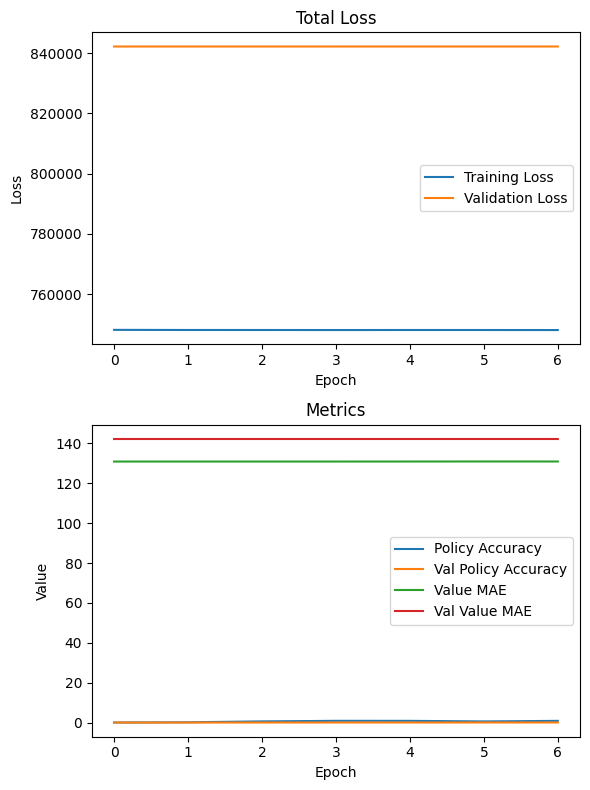

In [ ]:
def train_chess_model(model, dataset_path, epochs=10, batch_size=64, validation_split=0.2, learning_rate=0.001, save_dir = '/content/drive/MyDrive/CNT 4149 Deep Learning/model/default_dir.keras'):
    """
    Train a chess AI model on a preprocessed chess dataset.

    Parameters:
    -----------
    model : tf.keras.Model
        The chess model to train, with policy and value heads
    dataset_path : str
        Path to the preprocessed dataset (NumPy format)
    epochs : int
        Number of training epochs
    batch_size : int
        Batch size for training
    validation_split : float
        Fraction of data to use for validation
    learning_rate : float
        Learning rate for the optimizer

    Returns:
    --------
    history : History object
        Keras training history
    """
    import tensorflow as tf
    import numpy as np
    import matplotlib.pyplot as plt

    # Load preprocessed data
    print(f"Loading data from {path}...")
    data = np.load(path)
    X = data['positions']  # Expected shape: (num_samples, 8, 8, 14)
    y_policy = data['policy_targets']  # Expected shape: (num_samples, 64*64*5)
    y_value = data['value_targets']  # Expected shape: (num_samples, 1)
    # data load part needs to be rewritten to match current code

    print(f"Loaded {len(X)} positions")
    print(f"Input shape: {X.shape}")
    print(f"Policy targets shape: {y_policy.shape}")
    print(f"Value targets shape: {y_value.shape}")

    # Define optimizer and loss functions
    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)

    model.compile(
        optimizer=optimizer,
        loss={
            'policy': 'categorical_crossentropy',
            'value': 'mean_squared_error'
        },
        metrics={
            'policy': 'categorical_accuracy',
            'value': 'mae'
        }
    )

    # Define callbacks
    callbacks = [
        tf.keras.callbacks.ModelCheckpoint(
            'chess_model_best.keras',
            save_best_only=True,
            monitor='val_loss'
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=3,
            min_lr=1e-5
        ),
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=5,
            restore_best_weights=True
        )
    ]

    # Train the model
    print("Starting training...")
    history = model.fit(
        X,
        {'policy': y_policy, 'value': y_value},
        batch_size=batch_size,
        epochs=epochs,
        validation_split=validation_split,
        callbacks=callbacks,
        verbose=1
    )

    # Save the final model
    model.save(model_save_dir + save_name)
    print(f"Model saved as {save_name}")

    return history






# Example usage
if __name__ == "__main__":
    import tensorflow as tf

    # Import the model creation function you provided

    # Create the model
    model = create_chess_model()

    # Print model summary
    model.summary()


    # List of dataset files
    dataset_files = [
        '/content/drive/MyDrive/CNT 4149 Deep Learning/chess_dataset/chess_dataset_randomized.npz',
        '/content/drive/MyDrive/CNT 4149 Deep Learning/chess_dataset/shuffled_chess_dataset.npz'
    ]


    path = '/content/drive/MyDrive/CNT 4149 Deep Learning/chess_dataset/chess_dataset_randomized.npz'
    model_save_dir = '/content/drive/MyDrive/CNT 4149 Deep Learning/model/'
    save_name= "chess_model_randomtest.keras"

    # Train the model
    history = train_chess_model(
        model=model,
        dataset_path=path,
        epochs=20,
        batch_size=128,
        validation_split=0.2,
        learning_rate=0.001,
        save_dir = model_save_dir + save_name
    )

    # Plot training history
    plot_training_history(history)

In [ ]:
model.summary()

# Model Visualisation

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import chess
import seaborn as sns
from PIL import Image


visualization_path = '/content/drive/MyDrive/CNT 4149 Deep Learning/visualization/'

# Assuming model is your trained chess CNN model
# And board_to_input_fn is your function to convert a chess board to model input

def visualize_model_architecture(model):
    """Visualize the model architecture"""
    # Print the model summary
    model.summary()

    # Create a more visual representation
    tf.keras.utils.plot_model(
        model,
        to_file= visualization_path + 'model_architecture.png',
        show_shapes=True,
        show_dtype=True,
        show_layer_names=True,
        rankdir='TB',  # 'TB' for top to bottom, 'LR' for left to right
        dpi=96,
        expand_nested=True
    )

    print(f"Model architecture saved to 'model_architecture.png'")

def visualize_filters(model, layer_name=None):
    """Visualize the filters in a convolutional layer"""
    # If no layer specified, find the first convolutional layer
    if layer_name is None:
        for layer in model.layers:
            if 'conv' in layer.name.lower():
                layer_name = layer.name
                break

    # Get the layer
    layer = model.get_layer(layer_name)

    # Get the weights
    weights = layer.get_weights()[0]

    # Normalize weights for better visualization
    weights = (weights - weights.min()) / (weights.max() - weights.min())

    # Create the figure
    n_filters = weights.shape[3]
    n_channels = weights.shape[2]

    fig, axes = plt.subplots(n_channels, n_filters, figsize=(n_filters, n_channels))

    # Plot each filter for each input channel
    for i in range(n_channels):
        for j in range(n_filters):
            if n_channels > 1:
                ax = axes[i, j]
            else:
                ax = axes[j]
            ax.imshow(weights[:, :, i, j], cmap='viridis')
            ax.axis('off')

    plt.tight_layout()
    plt.savefig(visualization_path + f'filters_{layer_name}.png', dpi=150)
    plt.close()

    print(f"Filter visualization for layer '{layer_name}' saved")

def visualize_feature_maps(model, board, layer_names=None):
    """Visualize feature maps for a specific input"""
    # Convert board to model input
    input_tensor = board_to_features(board)
    input_tensor = np.expand_dims(input_tensor, axis=0)  # Add batch dimension

    # If no layers specified, use all convolutional layers
    if layer_names is None:
        layer_names = []
        for layer in model.layers:
            if 'conv' in layer.name.lower():
                layer_names.append(layer.name)

    # Create feature extractor models
    for layer_name in layer_names:
        feature_model = tf.keras.Model(
            inputs=model.input,
            outputs=model.get_layer(layer_name).output
        )

        # Get feature maps
        features = feature_model.predict(input_tensor)
        features = features[0]  # Remove batch dimension

        # Plot feature maps
        n_features = features.shape[-1]
        grid_size = int(np.ceil(np.sqrt(n_features)))

        fig, axes = plt.subplots(grid_size, grid_size, figsize=(grid_size*2, grid_size*2))
        axes = axes.flatten()

        for i in range(n_features):
            axes[i].imshow(features[:, :, i], cmap='viridis')
            axes[i].set_title(f'Feature {i+1}')
            axes[i].axis('off')

        # Hide unused subplots
        for i in range(n_features, len(axes)):
            axes[i].axis('off')

        plt.tight_layout()
        plt.savefig(visualization_path + f'feature_maps_{layer_name}.png', dpi=150)
        plt.close()
        plt.show()

        print(f"Feature maps for layer '{layer_name}' saved")

def visualize_policy_heatmap(model, board):
    """Visualize the policy output as a heatmap on the chess board"""
    # Get model prediction
    input_tensor = board_to_features(board)
    input_tensor = np.expand_dims(input_tensor, axis=0)
    policy_output = model.predict(input_tensor)[0]

    # Reshape to 64x64 (from-to squares)
    policy_heatmap = np.zeros((8, 8, 8, 8))
    for from_sq in range(64):
        from_row, from_col = from_sq // 8, from_sq % 8
        for to_sq in range(64):
            to_row, to_col = to_sq // 8, to_sq % 8
            idx = from_sq * 64 + to_sq
            if idx < len(policy_output):
                policy_heatmap[from_row, from_col, to_row, to_col] = policy_output[idx][0]

    # Create visualization for each piece on the board
    fig, axes = plt.subplots(8, 8, figsize=(12, 12))

    for from_row in range(8):
        for from_col in range(8):
            ax = axes[from_row, from_col]

            # Get piece at this position
            sq = chess.square(from_col, 7-from_row)  # Chess uses different coordinates
            piece = board.piece_at(sq)

            if piece is None:
                # Empty square
                ax.imshow(np.zeros((8, 8)), cmap='Greys', vmin=0, vmax=1)
            else:
                # Show heatmap of where this piece is likely to move
                hm = policy_heatmap[from_row, from_col]
                ax.imshow(hm, cmap='hot', vmin=0, vmax=hm.max() if hm.max() > 0 else 1)

            # Add piece symbol if present
            if piece:
                ax.text(3.5, 4.0, chess.UNICODE_PIECE_SYMBOLS[piece.symbol()],
                        fontsize=20, ha='center', va='center',
                        color='white' if piece.color == chess.BLACK else 'black')

            # Set square color for the board
            if (from_row + from_col) % 2 == 0:
                ax.patch.set_facecolor('lightgray')
            else:
                ax.patch.set_facecolor('darkgray')

            ax.set_xticks([])
            ax.set_yticks([])

    plt.tight_layout()
    plt.savefig(visualization_path + 'policy_heatmap.png', dpi=200)
    plt.show()
    plt.close()

    print("Policy heatmap visualization saved to 'policy_heatmap.png'")

def visualize_attention(model, board):
    """
    Create a heatmap showing where the model is paying attention.

    Note: This requires a model with attention mechanisms or we
    use Grad-CAM as an alternative.
    """
    # This is a simplified Grad-CAM implementation
    input_tensor = board_to_features(board)
    input_tensor = np.expand_dims(input_tensor, axis=0)

    # Find the last convolutional layer
    last_conv_layer = None
    for layer in reversed(model.layers):
        if 'conv' in layer.name.lower():
            last_conv_layer = layer.name
            break

    if last_conv_layer:
        # Create a model that outputs both the final prediction and the activations
        grad_model = tf.keras.Model(
            inputs=model.input,
            outputs=[model.output, model.get_layer(last_conv_layer).output]
        )

        with tf.GradientTape() as tape:
            preds, conv_outputs = grad_model(input_tensor)
            # For simplicity, we'll just visualize attention for the highest probability move
            top_pred_idx = tf.argmax(preds[0][0])
            top_class_channel = preds[0][0, top_pred_idx]

        # Gradient of the top predicted class with respect to the output feature map
        grads = tape.gradient(top_class_channel, conv_outputs)

        # Global average pooling
        pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

        # Weight the channels by the gradients
        conv_outputs = conv_outputs[0]
        heatmap = tf.reduce_sum(tf.multiply(pooled_grads, conv_outputs), axis=-1)

        # Process the heatmap
        heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
        heatmap = heatmap.numpy()

        # Resize heatmap to 8x8 to match the chess board
        heatmap_resized = tf.image.resize(
            np.expand_dims(heatmap, axis=-1),
            (8, 8)
        ).numpy()[:,:,0]

        # Create visualization
        plt.figure(figsize=(10, 10))

        # Plot the board (simplified)
        board_img = np.zeros((8, 8, 3))
        for r in range(8):
            for c in range(8):
                if (r + c) % 2 == 0:
                    board_img[r, c] = [0.9, 0.9, 0.9]  # Light squares
                else:
                    board_img[r, c] = [0.5, 0.5, 0.5]  # Dark squares

                # Add pieces if present
                sq = chess.square(c, 7-r)
                piece = board.piece_at(sq)
                if piece:
                    piece_color = [1.0, 0.0, 0.0] if piece.color == chess.BLACK else [0.0, 0.0, 1.0]
                    board_img[r, c] = piece_color

        # Plot the board
        plt.imshow(board_img)

        # Overlay the heatmap
        plt.imshow(heatmap_resized, cmap='jet', alpha=0.7)

        plt.title("Model Attention")
        plt.axis('off')
        plt.colorbar()
        plt.savefig(visualization_path + 'attention_map.png', dpi=200)
        plt.show()
        plt.close()

        print("Attention visualization saved to 'attention_map.png'")
    else:
        print("No convolutional layer found for attention visualization")



Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 8, 8, 14)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 8, 8, 64)  │      8,128 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 8, 8, 64)  │        256 │ conv2d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 8, 8, 64)  │     36,928 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 8, 8, 64)  │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 8, 8, 64)  │     36,928 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 8, 8, 64)  │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 8, 8, 64)  │          0 │ batch_normalizat… │
│                     │                   │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 8, 8, 64)  │          0 │ add[0][0]         │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 8, 8, 64)  │     36,928 │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 8, 8, 64)  │        256 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 8, 8, 64)  │     36,928 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 8, 8, 64)  │        256 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 8, 8, 64)  │          0 │ batch_normalizat… │
│                     │                   │            │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 8, 8, 64)  │          0 │ add_1[0][0]       │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 8, 8, 64)  │     36,928 │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 8, 8, 64)  │        256 │ conv2d_5[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 8, 8, 64)  │     36,928 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 8, 8, 64)  │        256 │ conv2d_6[0][0]    │
│ (BatchNormalizatio… │                   │            │                 

 Total params: 27,338,757 (104.29 MB)

 Trainable params: 9,112,321 (34.76 MB)

 Non-trainable params: 1,792 (7.00 KB)

 Optimizer params: 18,224,644 (69.52 MB)

Model architecture saved to 'model_architecture.png'
Filter visualization for layer 'conv2d' saved
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
Feature maps for layer 'conv2d' saved
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step
Feature maps for layer 'conv2d_1' saved
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
Feature maps for layer 'conv2d_2' saved
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step
Feature maps for layer 'conv2d_3' saved
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step
Feature maps for layer 'conv2d_4' saved
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 262ms/step
Feature maps for layer 'conv2d_5' saved
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 244ms/step
Feature maps for layer 'conv2d_6' saved
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 285ms/step
Feature maps for layer 'conv2d_7' saved
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 360ms/step
Feature maps for layer 'conv2d_8' saved
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 346ms/step
Feature maps for layer 'conv2d_9' saved
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 381ms/step
Feature maps for layer 'conv2d_10' saved
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 437ms/

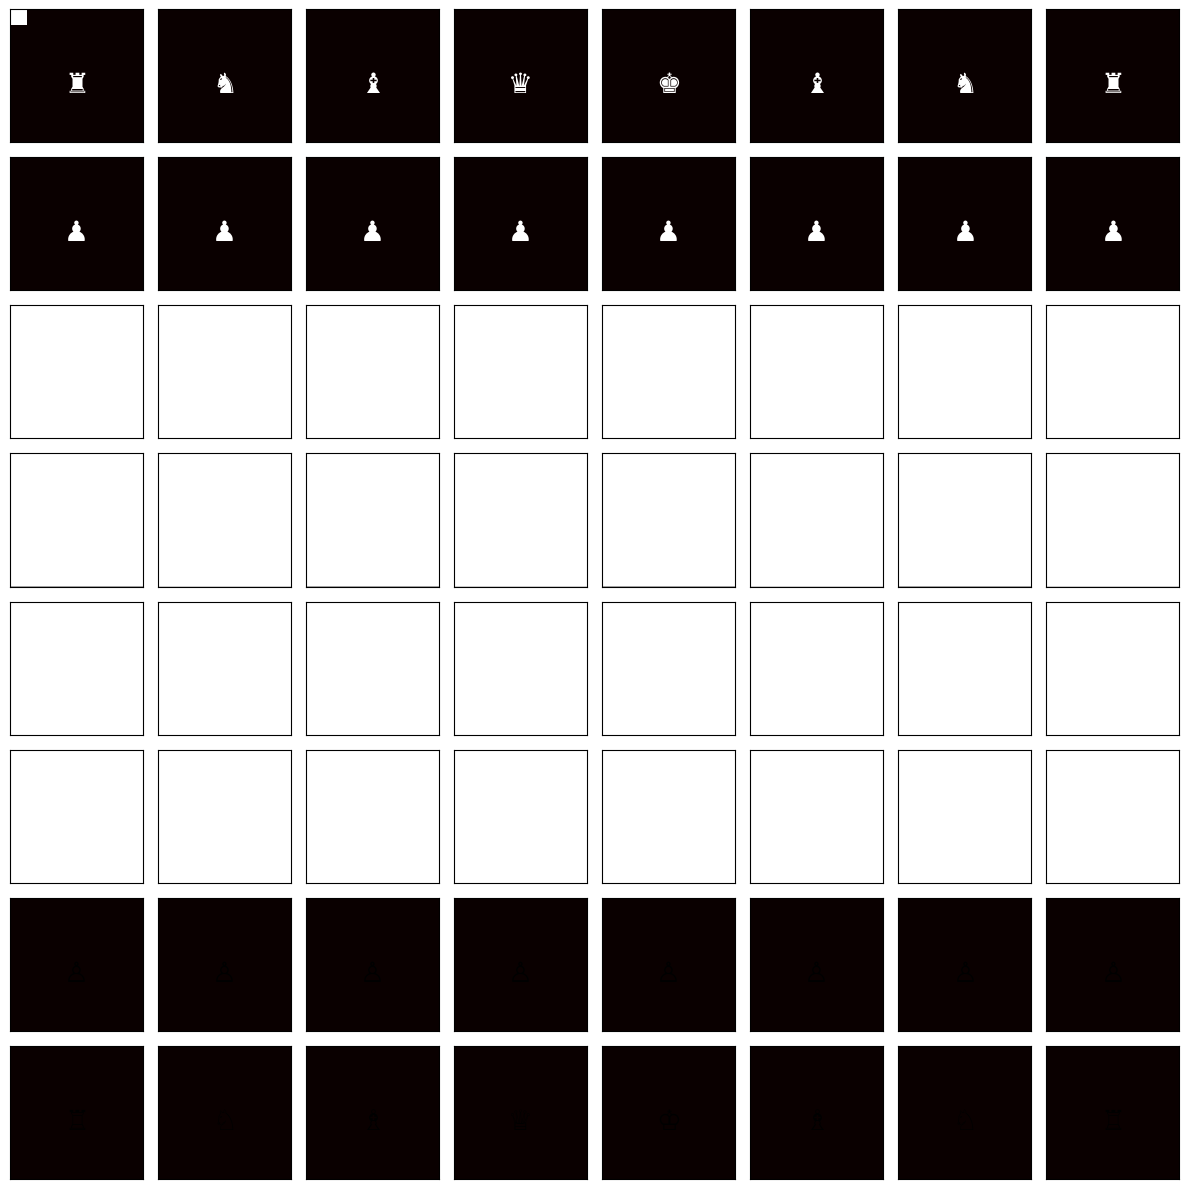

Policy heatmap visualization saved to 'policy_heatmap.png'


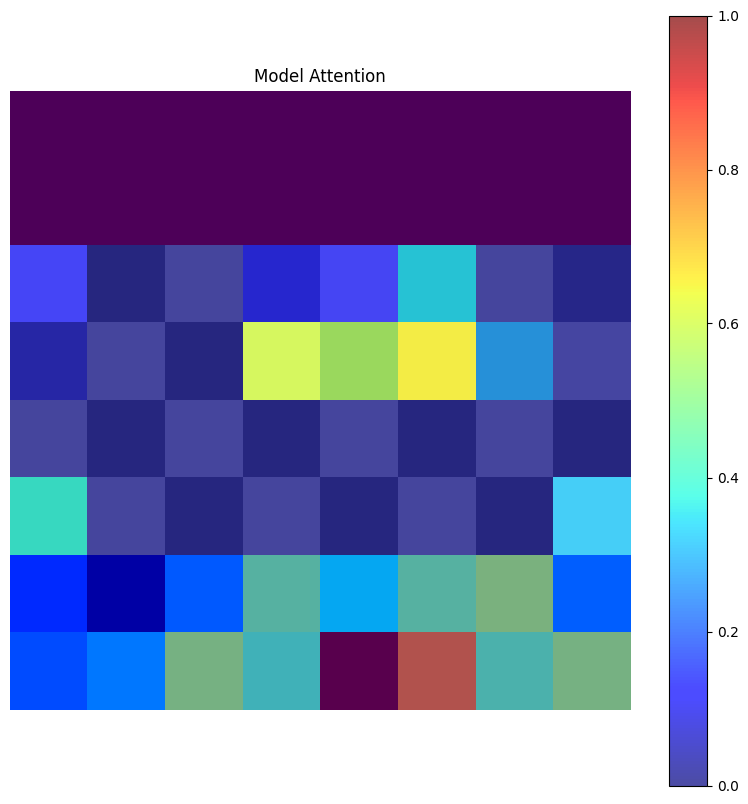

Attention visualization saved to 'attention_map.png'


In [ ]:
import tensorflow as tf
from PIL import Image

model_save_dir = '/content/drive/MyDrive/CNT 4149 Deep Learning/model/'
save_name= "chess_model_V2.keras"
# load model and run visial analysis
loaded_model = tf.keras.models.load_model(model_save_dir + save_name)

board = chess.Board()

visualize_model_architecture(loaded_model)
visualize_filters(loaded_model)
visualize_feature_maps(loaded_model, board)
visualize_policy_heatmap(loaded_model, board)
visualize_attention(loaded_model, board)

# Gameplay Test


In [ ]:
# code that pits the model against stockfish and records the results
import chess
import chess.engine
import tensorflow as tf
import numpy as np
import os
import time
from pathlib import Path


def play_tensorflow_vs_stockfish(
    tensorflow_model,
    num_games=10,
    stockfish_path="stockfish",
    stockfish_depth=10,
    stockfish_time=None,
    board_to_input_fn=None,
    ai_color="both",
    verbose=True,
    save_pgn=False,
    pgn_file="games.pgn"
):
    """
    Play a TensorFlow ML model against Stockfish for a set number of chess games.

    Parameters:
    -----------
    tensorflow_model : tf.keras.Model
        A TensorFlow model that takes a board representation as input and outputs move probabilities
    num_games : int
        Number of games to play
    stockfish_path : str
        Path to the Stockfish executable
    stockfish_depth : int
        Search depth for Stockfish (ignored if stockfish_time is provided)
    stockfish_time : float
        Time limit in seconds for Stockfish (if None, stockfish_depth is used)
    board_to_input_fn : function
        Function to convert a chess.Board to the input format required by the TensorFlow model
        If None, a default function will be used (assumes model expects 8x8x12 binary planes)
    ai_color : str
        "white", "black", or "both" to specify which color the TensorFlow model plays
    verbose : bool
        If True, print progress and game results
    save_pgn : bool
        If True, save games in PGN format
    pgn_file : str
        File path to save the PGN games

    Returns:
    --------
    dict
        Statistics about the games played
    """
    if board_to_input_fn is None:
        # Default function to convert board to model input
        # Assumes model expects an 8x8x12 binary tensor (6 piece types, 2 colors)
        board_to_input_fn = lambda board: board_to_features(board)

    # Initialize results tracking
    results = {
        "tensorflow_wins": 0,
        "stockfish_wins": 0,
        "draws": 0,
        "games": []
    }

    # Initialize Stockfish engine
    try:
        engine = chess.engine.SimpleEngine.popen_uci(stockfish_path)
        if stockfish_time is not None:
            engine_limit = chess.engine.Limit(time=stockfish_time)
        else:
            engine_limit = chess.engine.Limit(depth=stockfish_depth)
    except Exception as e:
        print(f"Error initializing Stockfish engine: {e}")
        return results

    # Open PGN file for writing if needed
    pgn_output = open(pgn_file, "w") if save_pgn else None

    for game_num in range(num_games):
        if verbose:
            print(f"\nStarting game {game_num + 1}/{num_games}")

        board = chess.Board()
        moves = []
        game_result = None

        # Add position history tracking
        position_history = []

        # Determine who plays which color in this game
        if ai_color == "both":
            tensorflow_color = game_num % 2 == 0
        elif ai_color == "white":
            tensorflow_color = True
        else:  # ai_color == "black"
            tensorflow_color = False

        while not board.is_game_over():

            # Record current position
            position_key = board.board_fen()
            position_history.append(position_key)

            # Current player is TensorFlow model
            if (board.turn == chess.WHITE) == tensorflow_color:
                # Get board representation for the model
                board_input = board_to_input_fn(board)
                board_input = np.expand_dims(board_input, axis=0)  # Add batch dimension

                # Get model prediction
                move_probabilities = tensorflow_model.predict(board_input, verbose=0)

                # Get legal moves and their probabilities
                legal_moves = list(board.legal_moves)
                legal_move_indices = [move_to_index(move) for move in legal_moves]
                legal_move_probs = [move_probabilities[0][idx] if idx < len(move_probabilities[0]) else 0
                                    for idx in legal_move_indices]

                # Apply repetition penalties
                for i, move in enumerate(legal_moves):
                    # Make a copy of the board to test this move
                    test_board = board.copy()
                    test_board.push(move)
                    test_position = test_board.board_fen()

                    # Count occurrences in history
                    occurrence_count = position_history.count(test_position)

                    # Apply penalty based on occurrence count
                    if occurrence_count > 0:
                        # Scale down the probability - stronger penalty for more repetitions
                        penalty = min(0.9, 0.7 * occurrence_count)  # Cap at 90% reduction
                        legal_move_probs[i] *= (1.0 - penalty)

                # Normalize probabilities if needed
                sum_probs = sum(legal_move_probs)
                if sum_probs > 0:
                    legal_move_probs = [prob / sum_probs for prob in legal_move_probs]



                # Choose the highest probability legal move
                if legal_move_probs:
                    best_move_idx = np.argmax(legal_move_probs)
                    move = legal_moves[best_move_idx]
                else:
                    # Fallback if there's an issue with move representation
                    move = legal_moves[0]

                if verbose:
                    print(f"TensorFlow plays: {move}")

            # Current player is Stockfish
            else:
                result = engine.play(board, engine_limit)
                move = result.move

                if verbose:
                    print(f"Stockfish plays: {move}")

            # Make the move
            board.push(move)
            moves.append(move)

            # Keep history at a reasonable size
            if len(position_history) > 20:
                position_history = position_history[-20:]


            if verbose:
                print(board)
                print("\n")

        # Game over, determine result
        if board.is_checkmate():
            # The side that just moved delivered checkmate
            winner = not board.turn
            if winner == tensorflow_color:
                results["tensorflow_wins"] += 1
                game_result = "1-0" if tensorflow_color else "0-1"
                if verbose:
                    print("TensorFlow wins by checkmate!")
            else:
                results["stockfish_wins"] += 1
                game_result = "0-1" if tensorflow_color else "1-0"
                if verbose:
                    print("Stockfish wins by checkmate!")
        else:
            results["draws"] += 1
            game_result = "1/2-1/2"
            if verbose:
                print("Game drawn:", end=" ")
                if board.is_stalemate():
                    print("Stalemate")
                elif board.is_insufficient_material():
                    print("Insufficient material")
                elif board.is_fifty_moves():
                    print("Fifty-move rule")
                elif board.is_repetition():
                    print("Threefold repetition")
                else:
                    print("Draw")

        # Save game details
        results["games"].append({
            "moves": [move.uci() for move in moves],
            "result": game_result,
            "tensorflow_color": "white" if tensorflow_color else "black"
        })

        # Save PGN if requested
        if save_pgn:
            game = chess.pgn.Game()
            game.headers["Event"] = "TensorFlow vs Stockfish"
            game.headers["Site"] = "Local Computer"
            game.headers["Date"] = time.strftime("%Y.%m.%d")
            game.headers["Round"] = str(game_num + 1)
            game.headers["White"] = "TensorFlow" if tensorflow_color else "Stockfish"
            game.headers["Black"] = "Stockfish" if tensorflow_color else "TensorFlow"
            game.headers["Result"] = game_result

            # Add moves to game
            node = game
            for move in moves:
                node = node.add_variation(move)

            print(game, file=pgn_output, end="\n\n")

    # Clean up
    engine.quit()
    if pgn_output:
        pgn_output.close()

    # Print summary
    if verbose:
        print("\nFinal results:")
        print(f"TensorFlow wins: {results['tensorflow_wins']}")
        print(f"Stockfish wins: {results['stockfish_wins']}")
        print(f"Draws: {results['draws']}")
        win_rate = (results['tensorflow_wins'] + 0.5 * results['draws']) / num_games * 100
        print(f"TensorFlow win rate: {win_rate:.1f}%")

    return results


def move_to_index(move):
    """
    Convert a chess move to a single index (0-4095).
    There are 64 possible from-squares and 64 possible to-squares.
    """
    from_idx = move.from_square
    to_idx = move.to_square
    return from_idx * 64 + to_idx

In [ ]:
# Play games

model_save_dir = '/content/drive/MyDrive/CNT 4149 Deep Learning/model/'
save_name= "chess_model_V1.h5"

model = tf.keras.models.load_model(model_save_dir + save_name)


results = play_tensorflow_vs_stockfish(
    tensorflow_model=model,
    num_games=1,
    stockfish_path="/usr/games/stockfish",  # Update with your path to Stockfish
    stockfish_depth=1,
    board_to_input_fn=board_to_features,
    ai_color="both",
    save_pgn=True
)


Starting game 1/1
TensorFlow plays: g1h3
r n b q k b n r
p p p p p p p p
. . . . . . . .
. . . . . . . .
. . . . . . . .
. . . . . . . N
P P P P P P P P
R N B Q K B . R


Stockfish plays: e7e5
r n b q k b n r
p p p p . p p p
. . . . . . . .
. . . . p . . .
. . . . . . . .
. . . . . . . N
P P P P P P P P
R N B Q K B . R


TensorFlow plays: h3g5
r n b q k b n r
p p p p . p p p
. . . . . . . .
. . . . p . N .
. . . . . . . .
. . . . . . . .
P P P P P P P P
R N B Q K B . R


Stockfish plays: d8g5
r n b . k b n r
p p p p . p p p
. . . . . . . .
. . . . p . q .
. . . . . . . .
. . . . . . . .
P P P P P P P P
R N B Q K B . R


TensorFlow plays: h1g1
r n b . k b n r
p p p p . p p p
. . . . . . . .
. . . . p . q .
. . . . . . . .
. . . . . . . .
P P P P P P P P
R N B Q K B R .


Stockfish plays: d7d5
r n b . k b n r
p p p . . p p p
. . . . . . . .
. . . p p . q .
. . . . . . . .
. . . . . . . .
P P P P P P P P
R N B Q K B R .


TensorFlow plays: g1h1
r n b . k b n r
p p p . . p p p
. . . . . .

# Versus Player

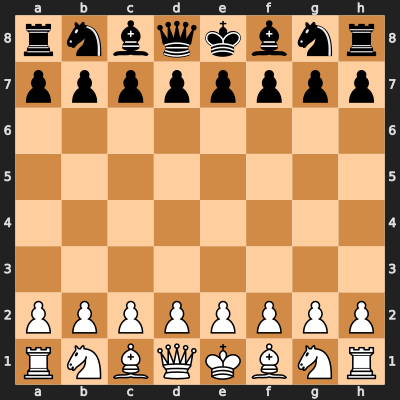

Starting game. You are white.


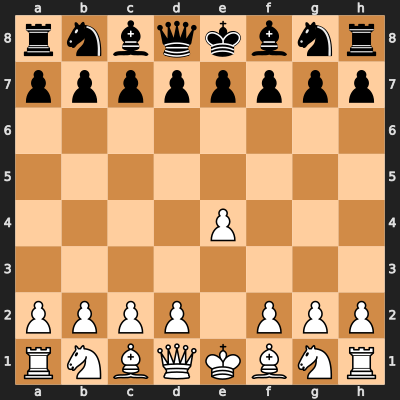

AI plays: b7b6


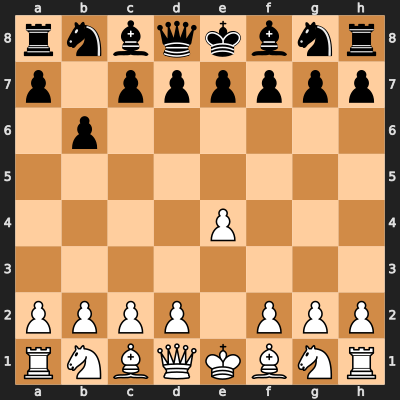

KeyboardInterrupt: Interrupted by user

In [ ]:
# prompt: code that allows the user to play against the chess ai model

import chess
import chess.engine
import numpy as np
import chess.svg
from IPython.display import SVG, display

# ... (Your existing code, including model loading and board_to_features) ...

def play_against_ai(model, stockfish_path="/usr/games/stockfish", stockfish_depth=1):
    """
    Plays a chess game against the AI model.
    """

    board = chess.Board()
    engine = chess.engine.SimpleEngine.popen_uci(stockfish_path)
    engine_limit = chess.engine.Limit(depth=stockfish_depth)


    display(SVG(chess.svg.board(board=board, size=400)))
    print("Starting game. You are white.")

    while not board.is_game_over():
        if board.turn == chess.WHITE:
            # Get player's move
            move_str = input("Enter your move (e.g., e2e4): ")

            try:
                move = chess.Move.from_uci(move_str)
                if move in board.legal_moves:
                    board.push(move)
                else:
                    print("Invalid move. Please try again.")
                    continue  # Go back to the beginning of the loop
            except ValueError:
                print("Invalid move format. Please try again.")
                continue
        else:
            # AI's turn
            board_input = board_to_features(board)
            board_input = np.expand_dims(board_input, axis=0)
            move_probabilities, _ = model.predict(board_input, verbose=0)

            legal_moves = list(board.legal_moves)
            legal_move_indices = [move_to_index(move) for move in legal_moves]
            legal_move_probs = [move_probabilities[0][idx] for idx in legal_move_indices]

            if legal_move_probs:
                best_move_idx = np.argmax(legal_move_probs)
                move = legal_moves[best_move_idx]
            else:
              result = engine.play(board, engine_limit)
              move = result.move


            board.push(move)
            print("AI plays:", move)

        #print(board)
        display(SVG(chess.svg.board(board=board, size=400)))
    engine.quit()

    if board.is_checkmate():
        print(f"{'AI' if board.turn == chess.WHITE else 'Player'} wins by checkmate!")
    else:
        print("Draw!")

# Example usage:
if __name__ == "__main__":

  # ... (Your existing code) ...  Load your model here.
  # Replace 'your_model_path' with the actual path to your model file.
  #model = tf.keras.models.load_model('/content/drive/MyDrive/CNT 4149 Deep Learning/model/chess_model_final.h5')
  play_against_ai(model)
